# Exploratory Data Analysis - Bank Transaction Dataset

Analisis eksploratif dataset transaksi bank buat ngidentifikasi pola-pola yang mencurigakan.
Dataset ini dari Kaggle (Bank Transaction Dataset for Fraud Detection), isinya 2500-an record transaksi dengan berbagai atribut.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Load Data dan Overview Awal

Pertama kita load dulu datanya dan liat sekilas bentuknya kayak gimana - berapa baris, kolom apa aja, tipe datanya, dll.

In [2]:
df = pd.read_csv('../data/bank_transactions_data_2.csv')
print(f'Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset shape: 2512 rows, 16 columns


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   str    
 1   AccountID                2512 non-null   str    
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   str    
 4   TransactionType          2512 non-null   str    
 5   Location                 2512 non-null   str    
 6   DeviceID                 2512 non-null   str    
 7   IP Address               2512 non-null   str    
 8   MerchantID               2512 non-null   str    
 9   Channel                  2512 non-null   str    
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   str    
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance           2512 non-n

In [4]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [5]:
# cek missing values
missing = df.isnull().sum()
missing[missing > 0] if missing.sum() > 0 else print('Tidak ada missing values')

Tidak ada missing values


In [6]:
# cek duplikat
print(f'Jumlah duplikat: {df.duplicated().sum()}')
print(f'Unique TransactionID: {df["TransactionID"].nunique()} dari {len(df)} rows')

Jumlah duplikat: 0
Unique TransactionID: 2512 dari 2512 rows


## 2. Distribusi Variabel Numerik

Kita liat distribusi dari variabel-variabel numerik utama. Ini penting buat tau apakah datanya skewed, ada outlier, atau pola tertentu yang perlu diperhatiin.

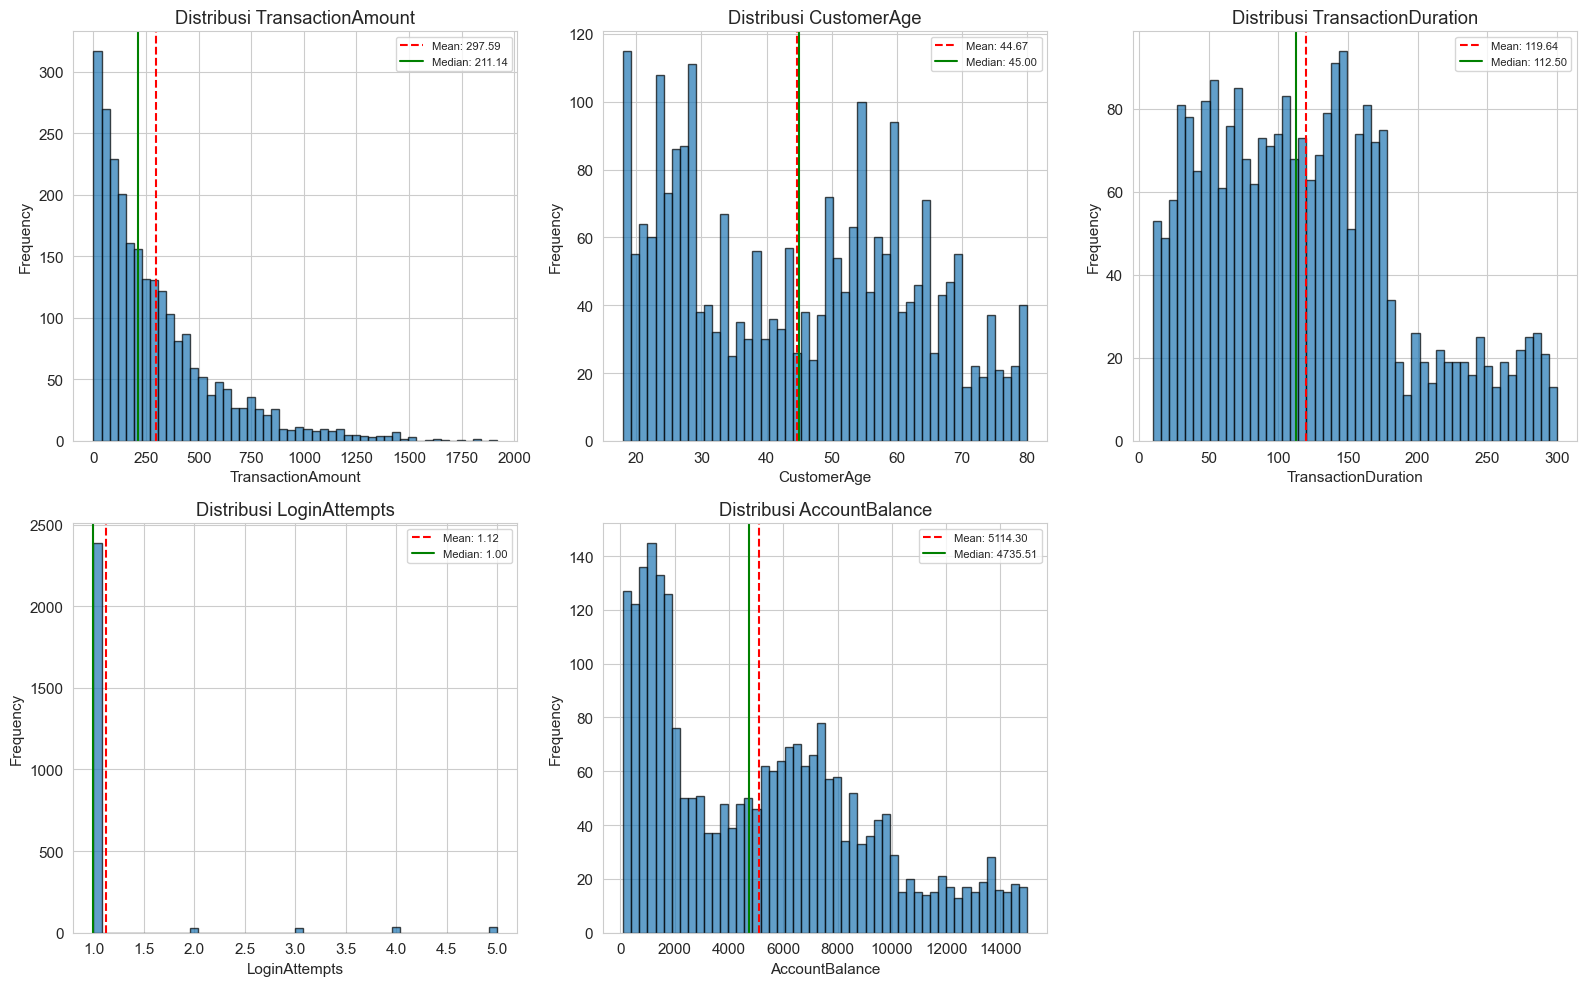

In [7]:
num_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    
    # tambahin garis mean dan median
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='-', label=f'Median: {df[col].median():.2f}')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

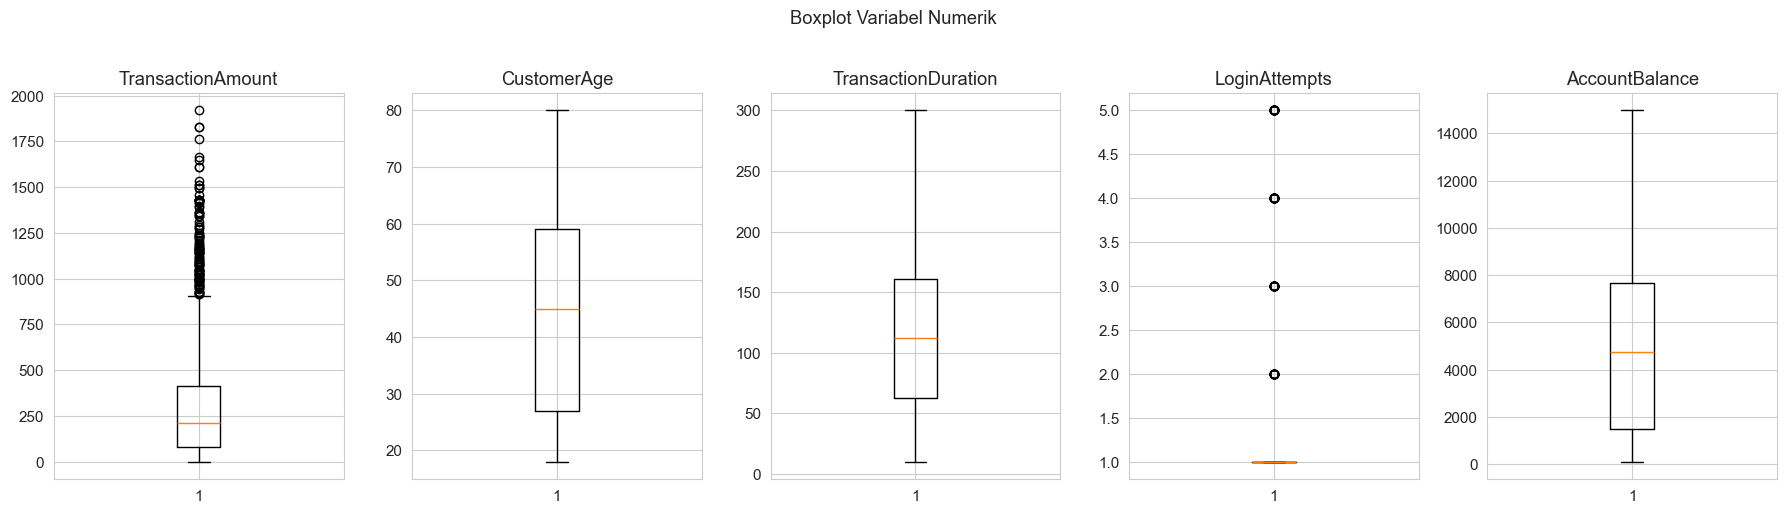

In [8]:
# boxplot untuk lihat outlier
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col)

plt.suptitle('Boxplot Variabel Numerik', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# summary statistik per variabel numerik
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: range [{df[col].min():.2f}, {df[col].max():.2f}], IQR outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')

TransactionAmount: range [0.26, 1919.11], IQR outliers: 113 (4.5%)
CustomerAge: range [18.00, 80.00], IQR outliers: 0 (0.0%)
TransactionDuration: range [10.00, 300.00], IQR outliers: 0 (0.0%)
LoginAttempts: range [1.00, 5.00], IQR outliers: 122 (4.9%)
AccountBalance: range [101.25, 14977.99], IQR outliers: 0 (0.0%)


## 3. Distribusi Variabel Kategorikal

Selain numerik, kita juga perlu liat sebaran dari variabel kategorikal kayak tipe transaksi, channel, occupation, dan lokasi.

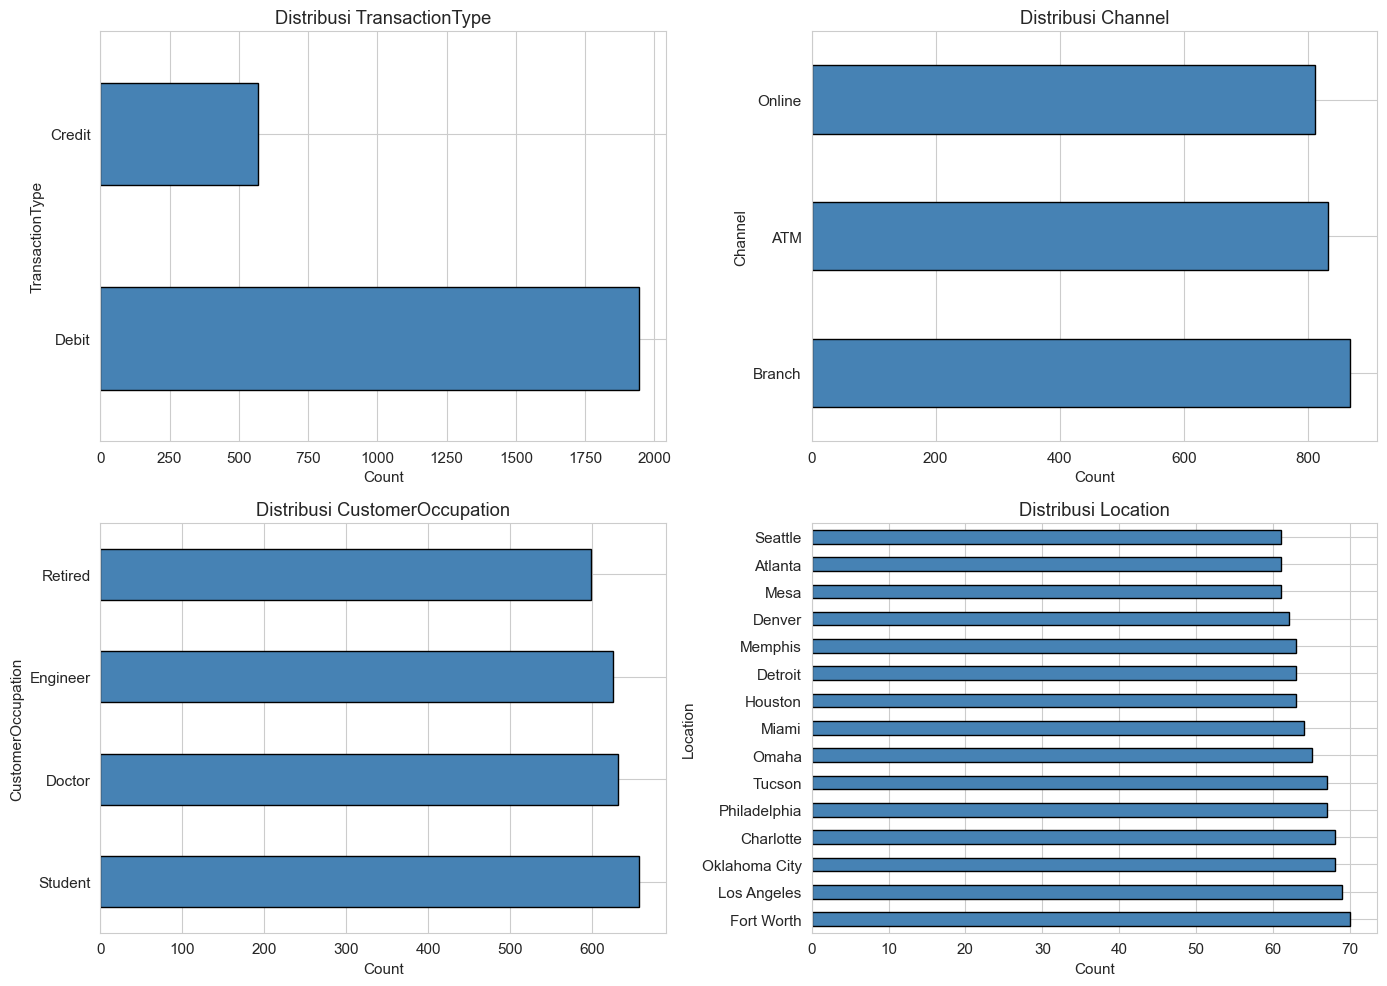

In [10]:
cat_cols = ['TransactionType', 'Channel', 'CustomerOccupation', 'Location']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    if len(counts) > 15:
        counts = counts.head(15)
    counts.plot(kind='barh', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel('Count')

plt.tight_layout()
plt.show()

In [11]:
# cardinality tiap kolom kategorikal
for col in ['TransactionType', 'Channel', 'CustomerOccupation', 'Location', 'DeviceID', 'MerchantID']:
    print(f'{col}: {df[col].nunique()} unique values')

TransactionType: 2 unique values
Channel: 3 unique values
CustomerOccupation: 4 unique values
Location: 43 unique values
DeviceID: 681 unique values
MerchantID: 100 unique values


## 4. Analisis Temporal

Sekarang kita coba ekstrak informasi waktu dari TransactionDate. Jam berapa transaksi paling banyak terjadi? Apakah ada pola di hari tertentu?

In [12]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])

df['TxnHour'] = df['TransactionDate'].dt.hour
df['TxnDayOfWeek'] = df['TransactionDate'].dt.dayofweek
df['TxnMonth'] = df['TransactionDate'].dt.month
df['DaysSincePrevTxn'] = (df['TransactionDate'] - df['PreviousTransactionDate']).dt.days

print(f"Rentang transaksi: {df['TransactionDate'].min()} s/d {df['TransactionDate'].max()}")
print(f"Rentang previous txn: {df['PreviousTransactionDate'].min()} s/d {df['PreviousTransactionDate'].max()}")

Rentang transaksi: 2023-01-02 16:00:06 s/d 2024-01-01 18:21:50
Rentang previous txn: 2024-11-04 08:06:23 s/d 2024-11-04 08:12:23


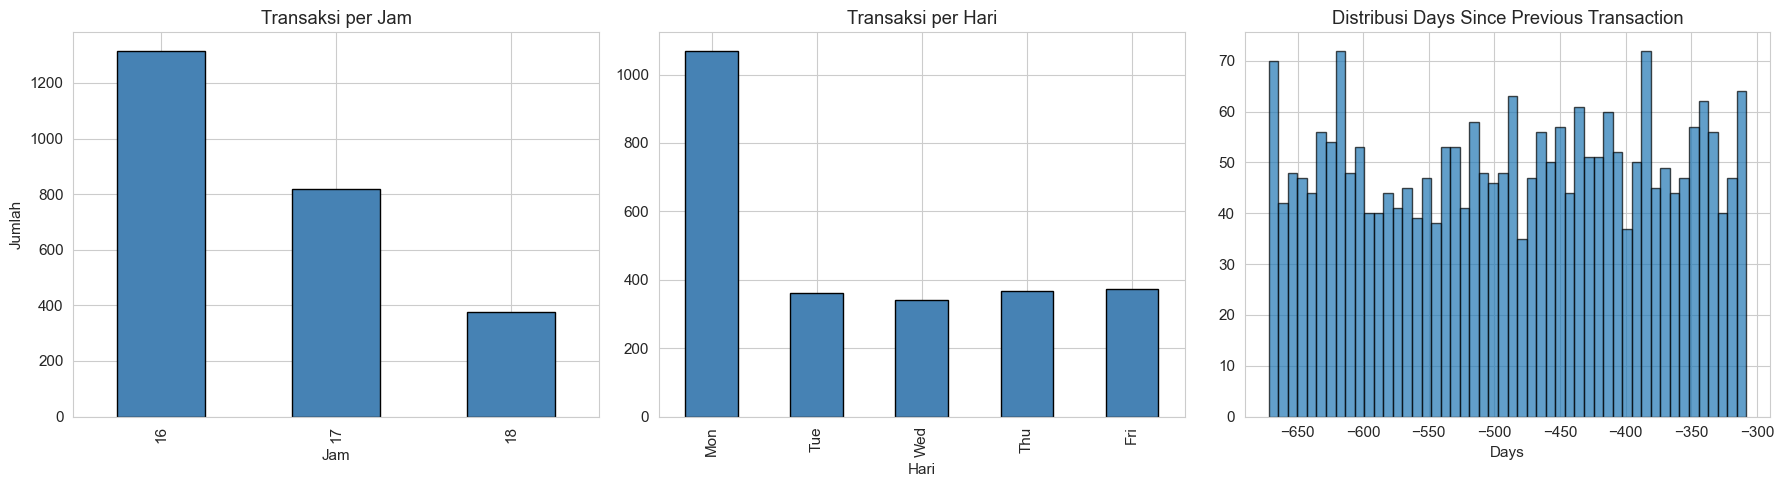

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# distribusi jam transaksi
df['TxnHour'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Transaksi per Jam')
axes[0].set_xlabel('Jam')
axes[0].set_ylabel('Jumlah')

# distribusi hari
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = df['TxnDayOfWeek'].value_counts().sort_index()
day_counts.index = [day_names[i] for i in day_counts.index]
day_counts.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Transaksi per Hari')
axes[1].set_xlabel('Hari')

# distribusi DaysSincePrevTxn
axes[2].hist(df['DaysSincePrevTxn'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[2].set_title('Distribusi Days Since Previous Transaction')
axes[2].set_xlabel('Days')

plt.tight_layout()
plt.show()

## 5. Korelasi antar Variabel Numerik

Liat korelasi antar fitur numerik. Kalo ada fitur yang highly correlated, bisa jadi redundant nanti di modeling.

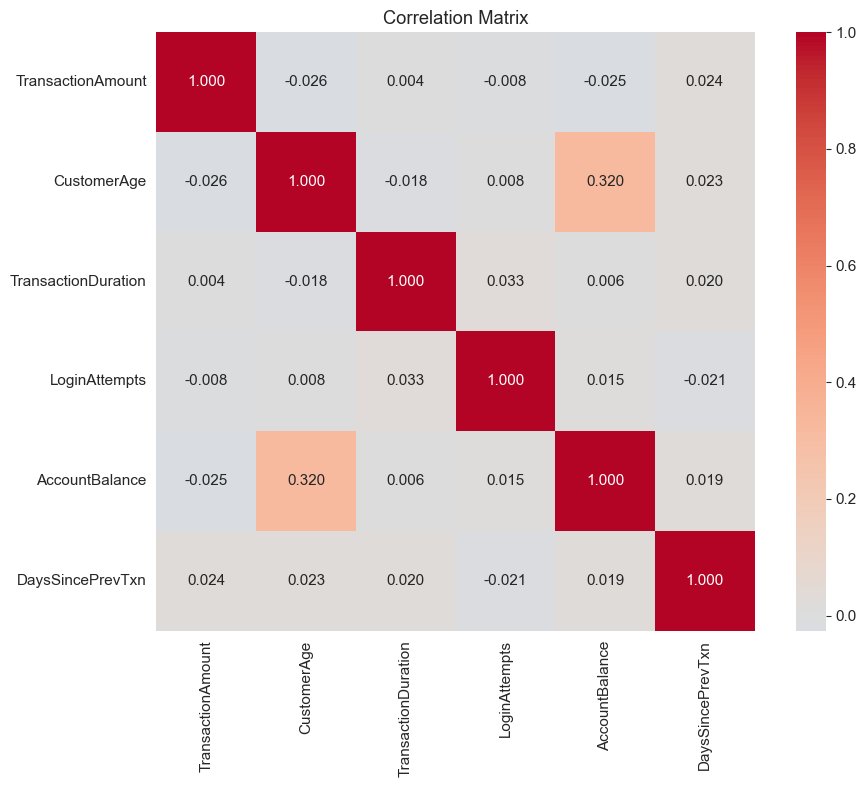

In [14]:
corr_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'DaysSincePrevTxn']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

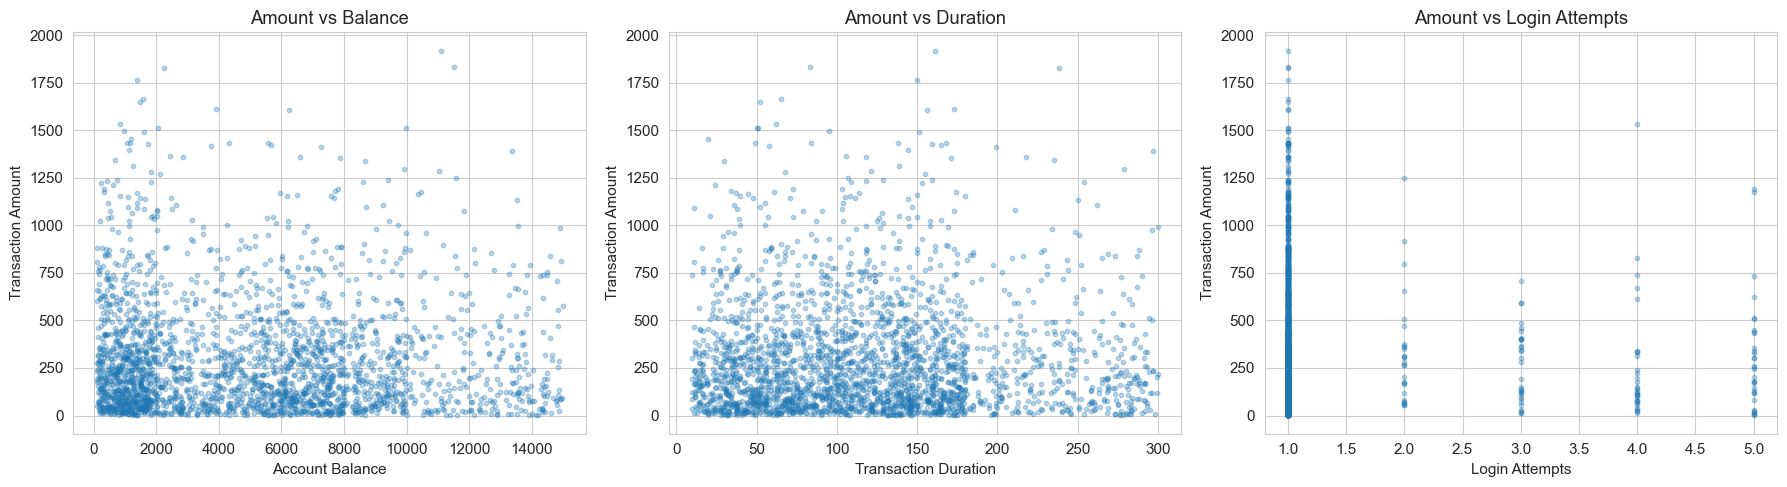

In [15]:
# scatter plot: TransactionAmount vs AccountBalance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df['AccountBalance'], df['TransactionAmount'], alpha=0.3, s=10)
axes[0].set_xlabel('Account Balance')
axes[0].set_ylabel('Transaction Amount')
axes[0].set_title('Amount vs Balance')

axes[1].scatter(df['TransactionDuration'], df['TransactionAmount'], alpha=0.3, s=10)
axes[1].set_xlabel('Transaction Duration')
axes[1].set_ylabel('Transaction Amount')
axes[1].set_title('Amount vs Duration')

axes[2].scatter(df['LoginAttempts'], df['TransactionAmount'], alpha=0.3, s=10)
axes[2].set_xlabel('Login Attempts')
axes[2].set_ylabel('Transaction Amount')
axes[2].set_title('Amount vs Login Attempts')

plt.tight_layout()
plt.show()

## 6. Identifikasi Pola Anomali

Di sini kita coba gali lebih dalam pola-pola yang bisa jadi indikator fraud:
- Transaksi dengan amount yang ga proporsional sama balance
- Login attempts yang tinggi (brute force?)
- Perbedaan behavior per channel
- Transaksi di jam-jam ga wajar
- Account yang pake banyak device / lokasi

In [16]:
# transaksi dengan amount sangat tinggi relatif terhadap balance
df['AmountToBalanceRatio'] = df['TransactionAmount'] / (df['AccountBalance'] + 1)

print('Top 10 transaksi dengan rasio amount/balance tertinggi:')
high_ratio = df.nlargest(10, 'AmountToBalanceRatio')[['TransactionID', 'TransactionAmount', 'AccountBalance', 'AmountToBalanceRatio', 'LoginAttempts', 'Channel']]
high_ratio

Top 10 transaksi dengan rasio amount/balance tertinggi:


,TransactionID,TransactionAmount,AccountBalance,AmountToBalanceRatio,LoginAttempts,Channel
2273,TX002274,806.97,102.20,7.819477,1,Online
2191,TX002192,879.25,125.85,6.931415,1,Online
1459,TX001460,659.71,106.86,6.116355,1,Branch
1258,TX001259,603.23,117.98,5.070012,1,Branch
2382,TX002383,761.73,151.28,5.002167,1,ATM
311,TX000312,1221.65,243.92,4.987955,1,Online
934,TX000935,1022.75,207.74,4.899636,1,Branch
450,TX000451,745.03,160.57,4.611190,1,Online
13,TX000014,781.76,189.69,4.099638,1,ATM
449,TX000450,689.29,168.84,4.058467,1,ATM


In [17]:
# transaksi dengan login attempts tinggi (potential brute force)
print(f'Distribusi LoginAttempts:')
print(df['LoginAttempts'].value_counts().sort_index())
print(f'\nTransaksi dengan LoginAttempts > 3: {len(df[df["LoginAttempts"] > 3])} ({len(df[df["LoginAttempts"] > 3])/len(df)*100:.1f}%)')

Distribusi LoginAttempts:
LoginAttempts
1    2390
2      27
3      31
4      32
5      32
Name: count, dtype: int64

Transaksi dengan LoginAttempts > 3: 64 (2.5%)


In [18]:
# analisis per channel: apakah ada channel tertentu yang punya pola beda
channel_stats = df.groupby('Channel').agg(
    avg_amount=('TransactionAmount', 'mean'),
    median_amount=('TransactionAmount', 'median'),
    avg_duration=('TransactionDuration', 'mean'),
    avg_login_attempts=('LoginAttempts', 'mean'),
    count=('TransactionID', 'count')
).round(2)

channel_stats

,avg_amount,median_amount,avg_duration,avg_login_attempts,count
Channel,,,,,
ATM,307.72,218.96,122.09,1.12,833
Branch,288.23,204.16,116.68,1.12,868
Online,297.21,206.63,120.31,1.13,811


In [19]:
# transaksi di jam-jam tidak wajar (misal dini hari) dengan amount tinggi
late_night = df[df['TxnHour'].between(0, 5)]
normal_hours = df[~df['TxnHour'].between(0, 5)]

print(f'Transaksi dini hari (00:00-05:59): {len(late_night)} ({len(late_night)/len(df)*100:.1f}%)')
print(f'Avg amount dini hari: {late_night["TransactionAmount"].mean():.2f}')
print(f'Avg amount jam normal: {normal_hours["TransactionAmount"].mean():.2f}')
print(f'Avg login attempts dini hari: {late_night["LoginAttempts"].mean():.2f}')
print(f'Avg login attempts jam normal: {normal_hours["LoginAttempts"].mean():.2f}')

Transaksi dini hari (00:00-05:59): 0 (0.0%)
Avg amount dini hari: nan
Avg amount jam normal: 297.59
Avg login attempts dini hari: nan
Avg login attempts jam normal: 1.12


In [20]:
# cek apakah ada account yang melakukan banyak transaksi dalam waktu singkat
acct_txn_count = df.groupby('AccountID').agg(
    txn_count=('TransactionID', 'count'),
    total_amount=('TransactionAmount', 'sum'),
    avg_amount=('TransactionAmount', 'mean'),
    unique_locations=('Location', 'nunique'),
    unique_devices=('DeviceID', 'nunique')
).sort_values('txn_count', ascending=False)

print('Accounts dengan transaksi terbanyak:')
acct_txn_count.head(10)

Accounts dengan transaksi terbanyak:


,txn_count,total_amount,avg_amount,unique_locations,unique_devices
AccountID,,,,,
AC00460,12,5570.34,464.195000,9,12
AC00363,12,4702.91,391.909167,11,12
AC00362,12,2991.32,249.276667,10,12
AC00202,12,3722.12,310.176667,11,12
AC00480,11,3309.50,300.863636,10,10
AC00257,11,3410.02,310.001818,11,11
AC00225,11,2926.30,266.027273,10,11
AC00456,11,3090.60,280.963636,9,11
AC00304,11,3651.80,331.981818,9,11


In [21]:
# account yang pakai banyak device atau lokasi berbeda (potential account takeover)
multi_device = acct_txn_count[acct_txn_count['unique_devices'] > 1]
multi_location = acct_txn_count[acct_txn_count['unique_locations'] > 1]

print(f'Accounts dengan >1 device: {len(multi_device)} ({len(multi_device)/df["AccountID"].nunique()*100:.1f}%)')
print(f'Accounts dengan >1 lokasi: {len(multi_location)} ({len(multi_location)/df["AccountID"].nunique()*100:.1f}%)')

Accounts dengan >1 device: 471 (95.2%)
Accounts dengan >1 lokasi: 470 (94.9%)


## 7. Ringkasan Temuan

Dari EDA yang udah dilakuin, beberapa poin penting:

**Data Overview:**
- Dataset 2,512 transaksi, 16 kolom. Ga ada missing values atau duplikat.

**Distribusi:**
- TransactionAmount skewed ke kanan - kebanyakan transaksi kecil, beberapa yang gede banget.
- CustomerAge cukup merata. LoginAttempts mayoritas 1, tapi ada yang sampai 5+.

**Pola Anomali:**
- Ada transaksi dengan rasio amount/balance yang sangat tinggi, ini suspicious.
- Beberapa account pake multiple device - bisa jadi account takeover.
- Transaksi dini hari (00-05) punya characteristics yang sedikit beda dari jam normal.

**Next Step:**
- Feature engineering dari temporal patterns dan ratio features.
- Pakai unsupervised approach (Isolation Forest, LOF) karena ga ada label fraud.